In [1]:
from gyraze_surrogate import surrogate_model
results = surrogate_model(4, 1.0, 2.5) 
#predicts mu for alpha=4, gamma=0.5, phi_wall=2.5

GYRAZE converged for α=4, γ=1.0, φ=2.5


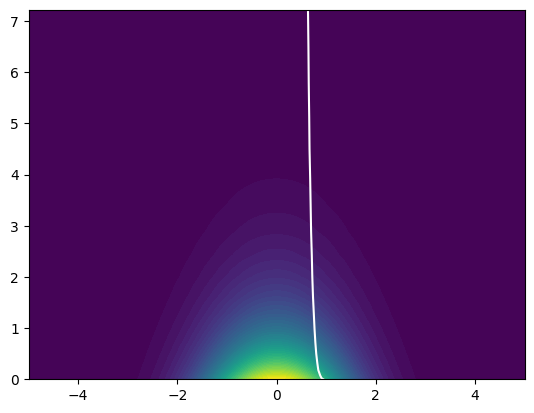

In [2]:
import numpy as np
import matplotlib.pyplot as plt
muvec = np.array([
    0.000000, 0.020000, 0.080000, 0.180000, 0.320000, 0.500000, 0.720000,
    0.980000, 1.280000, 1.620000, 2.000000, 2.420000, 2.880000, 3.380000,
    3.920000, 4.500000, 5.120000, 5.780000, 6.480000, 7.220000
])

# Define a maxwellian distribution function
def maxwellian(v, mu):
    return np.exp(-0.5 * v**2 - mu)

vvec = np.linspace(-5, 5, 100)

vv, mm = np.meshgrid(vvec, muvec)
zz = maxwellian(vv, mm)

figure, ax = plt.subplots()

ax.contourf(vv, mm, zz, levels=50, cmap='viridis')
ax.plot(results, muvec, label='alpha=10, gamma=1.0', color='white')

plt.show()

In [3]:
from export_to_c import generate_c_code

generate_c_code(
    nn_model      = "nn_model.pth",
    svm_model     = "svm_model.pkl",
    normalization = "normalization.npz",
    output_dir = "generated_c_code"
)

Generated generated_c_code/surrogate.c, generated_c_code/surrogate.h, generated_c_code/test_surrogate.c, generated_c_code/Makefile
Build: cd generated_c_code && make


In [4]:
import subprocess
import numpy as np

# --- Run the compiled C test program and capture output ---
proc = subprocess.run(
    ["./test_surrogate"],
    cwd="generated_c_code",
    capture_output=True, text=True
)
c_out = np.array([
    float(line.split("=")[1])
    for line in proc.stdout.strip().splitlines()
])

# --- Python reference (same inputs as test_surrogate.c: alpha=4, gamma=1.0, phi=2.5) ---
py_out = surrogate_model(4, 1.0, 2.5)

# --- Comparison ---
abs_err = np.abs(c_out - py_out)
print(f"{'i':>3}  {'C output':>14}  {'Python output':>14}  {'abs error':>12}")
print("-" * 50)
for i, (c, p, e) in enumerate(zip(c_out, py_out, abs_err)):
    print(f"{i:>3}  {c:>14.6f}  {p:>14.6f}  {e:>12.2e}")

print(f"\nMax absolute error : {abs_err.max():.2e}")
print(f"Mean absolute error: {abs_err.mean():.2e}")


GYRAZE converged for α=4, γ=1.0, φ=2.5
  i        C output   Python output     abs error
--------------------------------------------------
  0        0.940237        0.940237      4.32e-07
  1        0.907062        0.907062      5.37e-08
  2        0.876636        0.876636      2.83e-08
  3        0.840754        0.840754      2.71e-07
  4        0.820460        0.820460      3.20e-07
  5        0.798941        0.798941      3.41e-07
  6        0.781295        0.781295      3.00e-07
  7        0.764978        0.764979      7.66e-07
  8        0.750323        0.750323      4.15e-07
  9        0.733385        0.733385      4.44e-07
 10        0.719852        0.719853      8.05e-07
 11        0.709879        0.709879      1.98e-07
 12        0.695709        0.695709      3.48e-07
 13        0.686601        0.686601      1.62e-07
 14        0.676808        0.676808      3.58e-07
 15        0.663893        0.663893      1.35e-07
 16        0.657423        0.657423      4.96e-07
 17       